# Urban Mobility Price Analysis

## Business Problem

Ride-hailing platforms frequently offer different prices and estimated arrival times for the same route. The objective of this project is to compare Uber, DiDi, and InDrive to identify pricing patterns and determine which platform provides the best value depending on route and time of day.

## Dataset

The dataset consists of manually collected ride quotations created to validate the analysis workflow.

Each record includes:

- Date
- Time
- Origin
- Destination
- Price
- ETA
- Weather
- Rush Hour
- Day Period

In [38]:
#upload csv from pc
from google.colab import files
uploaded = files.upload()

Saving Urban_Mobility_Pilot_Dataset.csv to Urban_Mobility_Pilot_Dataset (3).csv


In [39]:
#set the stage
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Urban_Mobility_Pilot_Dataset.csv")

df.head()

,date,trip_id,time,weekday,origin,destination,uber_price,uber_eta,didi_price,didi_eta,indrive_price,indrive_eta,weather,rush_hour,day_period
0,2026-06-27 00:00:00,1,12:00:00,Saturday,Mundo E,Polanco,239.95,5,104.0,5,126.0,4,sunny,False,afternoon
1,2026-06-27 00:00:00,2,17:36:00,Saturday,Mundo E,Reforma,429.96,7,213.0,5,186.0,4,cloudy,False,afternoon
2,2026-06-27 00:00:00,3,17:47:00,Saturday,Mundo E,Coyoacán,289.94,5,210.0,5,242.0,4,cloudy,False,afternoon
3,2026-06-27 00:00:00,4,17:54:00,Saturday,Satélite,Roma Norte,239.94,5,161.0,4,160.0,4,cloudy,False,afternoon
4,2026-06-27 00:00:00,5,18:16:00,Saturday,Satélite,Santa Fe,509.95,4,162.0,6,196.0,4,cloudy,True,evening


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           30 non-null     object 
 1   trip_id        30 non-null     int64  
 2   time           30 non-null     object 
 3   weekday        30 non-null     object 
 4   origin         30 non-null     object 
 5   destination    30 non-null     object 
 6   uber_price     30 non-null     float64
 7   uber_eta       30 non-null     int64  
 8   didi_price     30 non-null     float64
 9   didi_eta       30 non-null     int64  
 10  indrive_price  30 non-null     float64
 11  indrive_eta    30 non-null     int64  
 12  weather        30 non-null     object 
 13  rush_hour      30 non-null     bool   
 14  day_period     30 non-null     object 
dtypes: bool(1), float64(3), int64(4), object(7)
memory usage: 3.4+ KB


In [41]:
df.describe()

,trip_id,uber_price,uber_eta,didi_price,didi_eta,indrive_price,indrive_eta
count,30.000000,30.000000,30.000000,30.00000,30.000000,30.000000,30.000000
mean,15.500000,340.288667,5.766667,256.10200,6.000000,261.970000,5.033333
std,8.803408,95.807531,1.887953,88.44969,1.144703,85.033817,1.299425
min,1.000000,189.950000,3.000000,104.00000,4.000000,126.000000,4.000000
25%,8.250000,249.935000,4.250000,167.72250,5.000000,188.500000,4.000000
50%,15.500000,347.205000,6.000000,238.45000,6.000000,241.555000,4.000000
75%,22.750000,422.955000,7.000000,340.58000,7.000000,355.725000,6.000000
max,30.000000,509.950000,9.000000,396.47000,8.000000,403.710000,8.000000


In [42]:
df.isnull().sum()

,0
date,0
trip_id,0
time,0
weekday,0
origin,0
destination,0
uber_price,0
uber_eta,0
didi_price,0
didi_eta,0


In [43]:
#What platform is the cheapest?
prices = df[["uber_price","didi_price","indrive_price"]].mean()

prices

,0
uber_price,340.288667
didi_price,256.102000
indrive_price,261.970000


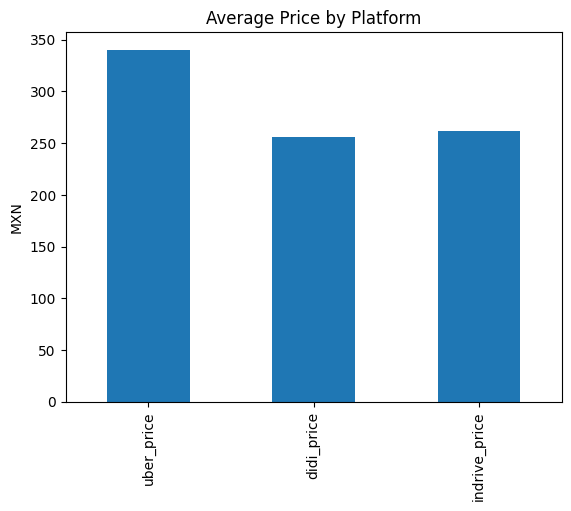

In [44]:
prices.plot(kind="bar")
plt.title("Average Price by Platform")
plt.ylabel("MXN")
plt.show()

In the gathering of this data, it was clear that the more expensive of the options was Uber by a significant margin. Didi and Indrive were close, but ultimately the cheaper of the options was Didi.

In [45]:
#What platform has the quickest ETA?
ETA = df[["uber_eta","didi_eta","indrive_eta"]].mean()

ETA

,0
uber_eta,5.766667
didi_eta,6.000000
indrive_eta,5.033333


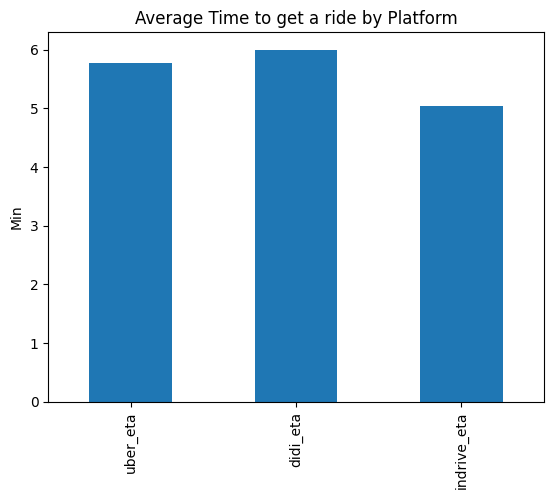

In [46]:
ETA.plot(kind="bar")
plt.title("Average Time to get a ride by Platform")
plt.ylabel("Min")
plt.show()

The quickest of the apps to get a ride, was Indrive, with Uber and Didi taking on avarage a minute longer to get a car to the customer.

In [55]:
#do prices change based on the time of day?
df.groupby("day_period")[["uber_price","didi_price","indrive_price"]].mean()

,uber_price,didi_price,indrive_price
day_period,,,
afternoon,321.07600,229.21900,237.38100
evening,300.18625,214.62125,228.79625
morning,413.26750,336.93000,337.53000
night,367.91750,290.77250,288.10000


In [56]:
df["route"] = df["origin"] + " → " + df["destination"]


In [57]:
#what are the most expensive routes?
df.groupby("route")["uber_price"].mean()

,uber_price
route,
Mundo E → Angel de la Independencia,345.670000
Mundo E → Coyoacán,283.835000
Mundo E → Polanco,303.770000
Mundo E → Reforma,429.960000
Plaza Satélite → Condesa,345.190000
Satélite → Roma Norte,274.750000
Satélite → Santa Fe,509.950000
Tlalnepantla Centro → Aeropuerto internacional Benito Juarez,349.253333
Tlalnepantla Centro → Centro Histórico,287.384000


In [58]:
#finding the cheapest platform
df["cheapest_platform"] = (
    df[["uber_price","didi_price","indrive_price"]]
    .idxmin(axis=1)
)

In [59]:
df["cheapest_platform"].value_counts()

,count
cheapest_platform,
didi_price,19
indrive_price,11


In [60]:
#finding the fastest platform
df["fastest_platform"] = (
    df[["uber_eta","didi_eta","indrive_eta"]]
    .idxmin(axis=1)
)

In [63]:
#Price diferences
df["price_range"] = (
    df[["uber_price","didi_price","indrive_price"]]
    .max(axis=1)
    -
    df[["uber_price","didi_price","indrive_price"]]
    .min(axis=1)
)

# Conclusions

This pilot analysis suggests that:

- Uber generally presented the highest average fares.
- InDrive offered the shortest estimated arrival time across the sampled routes.
- Price differences between platforms varied considerably depending on the selected route.
- The dataset demonstrates the feasibility of comparing ride-hailing services and could be expanded with additional real-world observations.

## Future Work

Future versions of this project will include:

- Larger datasets
- Automated data collection
- Interactive dashboards
- Statistical testing
- Predictive models